# Segmentación interactiva con GrabCut

Este cuaderno presenta el algoritmo **GrabCut** para la segmentación interactiva de lesiones en imágenes de resonancia magnética cerebral.

El método se estudiará en dos etapas:

1. **Implementación didáctica:** se desarrollarán paso a paso los principales componentes matemáticos de GrabCut: modelo de mezclas gaussianas, costos de apariencia, coherencia espacial, construcción del grafo y corte mínimo.
2. **Implementación con OpenCV:** se utilizará `cv2.grabCut` para observar cómo estos pasos son encapsulados por una implementación optimizada.

Finalmente, ambas segmentaciones se compararán con una máscara de referencia mediante el **error cuadrático medio (ECM)**.

In [1]:
%matplotlib widget

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

## 2. Imagen de trabajo

Sea $x_i$ la intensidad del píxel $i$ de una imagen en escala de grises.

Para desarrollar el algoritmo se utilizará un único caso como ejemplo. Cada caso del conjunto de datos está identificado mediante la convención `VS-SEG-XXX`.

La imagen original se encuentra en:

```text
data/images/
```

Durante las siguientes secciones, esta imagen permitirá construir paso a paso los modelos probabilísticos y espaciales utilizados por GrabCut.

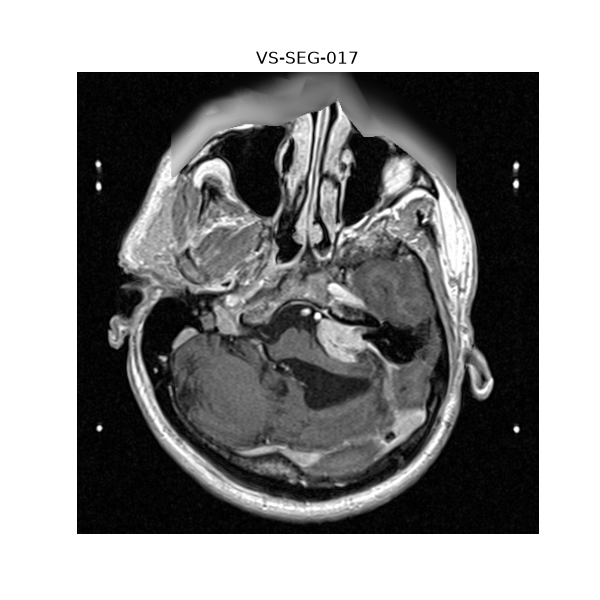

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

case_id = "VS-SEG-017"
image_path = DATA_DIR / "images" / f"{case_id}.png"

image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title(case_id)
plt.axis("off")
plt.show()

## 3. Selección interactiva de la ROI

GrabCut utiliza una **región de interés (ROI)** para inicializar la segmentación.

La ROI se representa mediante el rectángulo

$$
R=(x,y,w,h),
$$

donde $(x,y)$ corresponde a la esquina superior izquierda, mientras que $w$ y $h$ representan su ancho y altura.

El usuario selecciona una región que contiene la lesión y parte del tejido circundante. Los píxeles exteriores se utilizarán inicialmente como **fondo seguro**, mientras que los píxeles interiores constituirán la región candidata para la segmentación.

El rectángulo rojo puede reajustarse interactivamente y no representa el contorno final de la lesión; únicamente proporciona la inicialización espacial del algoritmo.

**Pausa de la exposición:** ejecute la celda siguiente, dibuje o ajuste el rectángulo y solo entonces continúe con la sección 4. Si cambia la ROI más tarde, vuelva a ejecutar desde la sección 4 para actualizar todos los resultados.

Las salidas guardadas muestran una ejecución de revisión con $R=(250,253,89,84)$ para el caso `VS-SEG-017`. Al volver a ejecutar, la selección sigue siendo manual; no se impone ese rectángulo.


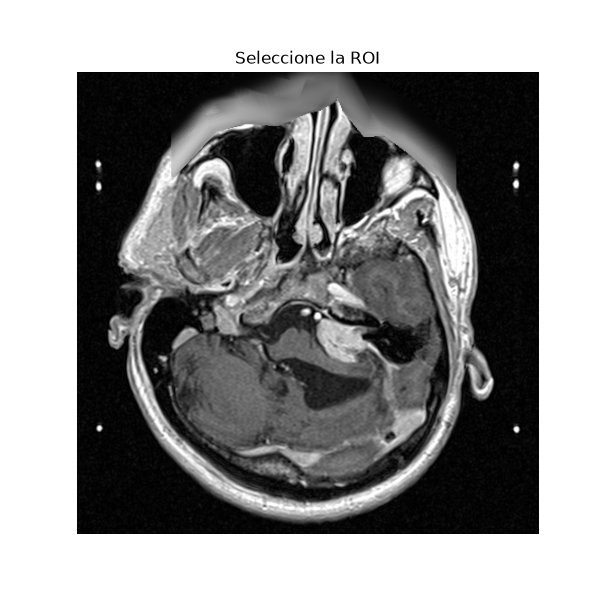

In [4]:
from IPython.display import display
from matplotlib.widgets import RectangleSelector

roi_state = {}


def on_select(eclick, erelease):
    x1, y1 = eclick.xdata, eclick.ydata
    x2, y2 = erelease.xdata, erelease.ydata

    roi_state["value"] = (
        int(min(x1, x2)),
        int(min(y1, y2)),
        int(abs(x2 - x1)),
        int(abs(y2 - y1)),
    )

    selector.ax.set_title(f"ROI = {roi_state['value']}")
    selector.ax.figure.canvas.draw_idle()


with plt.ioff():
    fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(image, cmap="gray")
ax.set_title("Seleccione la ROI")
ax.axis("off")

selector = RectangleSelector(
    ax,
    on_select,
    button=[1],
    interactive=True,
    useblit=False,
    props={
        "edgecolor": "red",
        "facecolor": "red",
        "alpha": 0.2,
        "fill": True,
    },
)

display(fig.canvas)

## 4. Inicialización de etiquetas

A cada píxel $i$ se le asigna una etiqueta provisional

$$
\alpha_i \in \{0,1\},
$$

donde

$$
\alpha_i =
\begin{cases}
0, & \text{si el píxel pertenece al fondo},\\
1, & \text{si el píxel pertenece a la región candidata}.
\end{cases}
$$

La ROI seleccionada en la sección anterior proporciona la inicialización:

- los píxeles **fuera** del rectángulo se consideran fondo seguro;
- los píxeles **dentro** del rectángulo se consideran provisionalmente parte de la región candidata.

Esta clasificación todavía no constituye la segmentación final. Su propósito es proporcionar muestras iniciales para estimar los modelos de apariencia de fondo y primer plano.

In [6]:
x, y, w, h = roi_state["value"]

labels = np.zeros_like(image, dtype=np.uint8)
labels[y:y + h, x:x + w] = 1

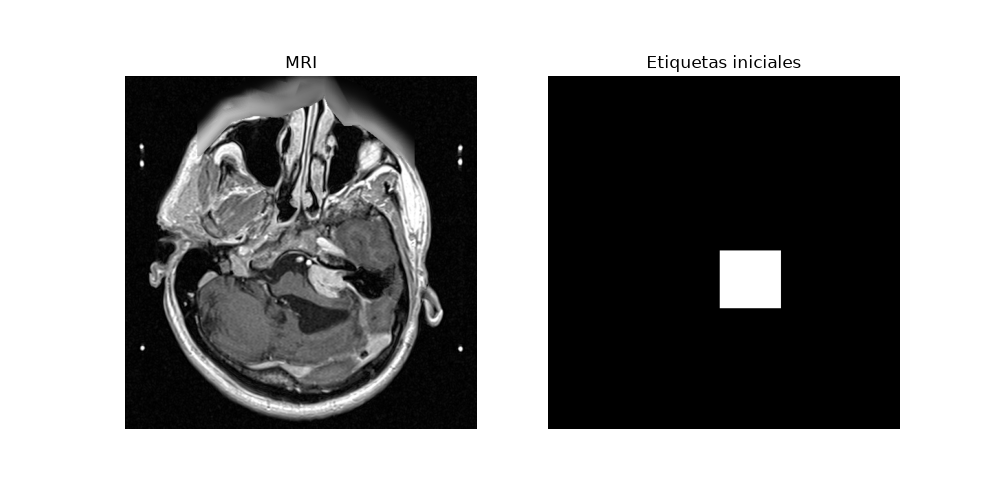

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("MRI")

axes[1].imshow(labels, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Etiquetas iniciales")

for ax in axes:
    ax.axis("off")

plt.show()

### 5.1. Muestras de fondo y primer plano

Se utilizarán $K=5$ componentes gaussianos para modelar cada clase.

A partir de las etiquetas iniciales $\alpha_i^{(0)}$, las intensidades se separan en dos conjuntos:

$$
X_{\mathrm{BG}}
=
\{x_i:\alpha_i^{(0)}=0\},
$$

$$
X_{\mathrm{FG}}
=
\{x_i:\alpha_i^{(0)}=1\}.
$$

El conjunto $X_{\mathrm{BG}}$ contiene las intensidades correspondientes al fondo seguro, mientras que $X_{\mathrm{FG}}$ contiene las intensidades de la región candidata.

Como la ROI incluye tanto la lesión como tejido circundante, $X_{\mathrm{FG}}$ no representa una única población homogénea. La mezcla de gaussianas permite representar distintos grupos de intensidades dentro de una misma clase.

In [8]:
K = 5

background_pixels = image[labels == 0].astype(np.float64)
foreground_pixels = image[labels == 1].astype(np.float64)

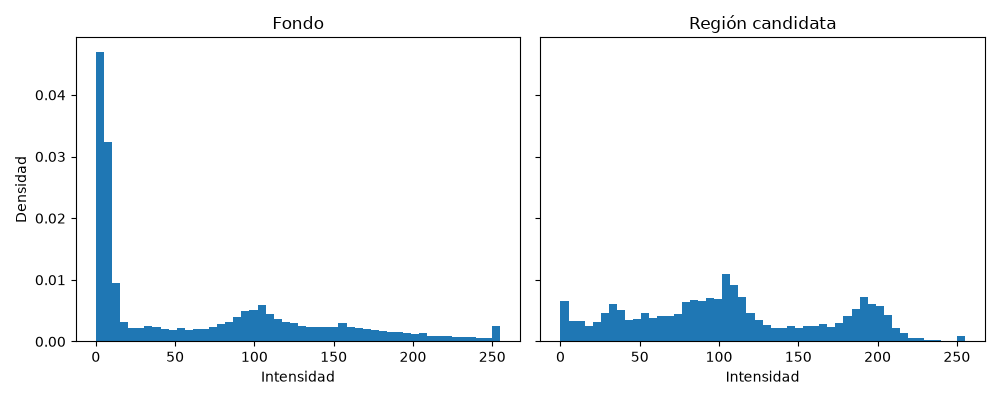

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(background_pixels, bins=50, density=True)
axes[0].set_title("Fondo")
axes[0].set_xlabel("Intensidad")

axes[1].hist(foreground_pixels, bins=50, density=True)
axes[1].set_title("Región candidata")
axes[1].set_xlabel("Intensidad")

axes[0].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

### 5.2. Inicialización de los componentes gaussianos

Antes de ajustar la mezcla es necesario proporcionar una estimación inicial de sus parámetros.

Para cada clase, las intensidades se ordenan y se dividen en $K=5$ grupos de tamaño aproximadamente igual:

$$
X_a = X_{a1} \cup X_{a2} \cup \cdots \cup X_{aK}.
$$

Para cada grupo $X_{ak}$ se calculan los parámetros iniciales

$$
w_{ak}
=
\frac{N_{ak}}{N_a},
$$

$$
\mu_{ak}
=
\frac{1}{N_{ak}}
\sum_{x_i \in X_{ak}} x_i,
$$

$$
\sigma_{ak}^2
=
\frac{1}{N_{ak}}
\sum_{x_i \in X_{ak}}
(x_i-\mu_{ak})^2,
$$

donde $N_{ak}$ es el número de píxeles asignados al componente $k$ y $N_a$ es el número total de píxeles de la clase.

Esta partición proporciona una inicialización simple y determinista de las cinco gaussianas. Posteriormente, los píxeles se reasignarán según el modelo probabilístico y los parámetros se volverán a estimar.

In [10]:
def initialize_gmm(samples, K):
    groups = np.array_split(np.sort(samples), K)

    weights = np.array([len(group) / len(samples) for group in groups])
    means = np.array([group.mean() for group in groups])
    variances = np.array([group.var() + 1e-6 for group in groups])

    return weights, means, variances

In [11]:
bg_weights, bg_means, bg_variances = initialize_gmm(background_pixels, K)
fg_weights, fg_means, fg_variances = initialize_gmm(foreground_pixels, K)

In [12]:
print("Background")
print("weights:   ", np.round(bg_weights, 3))
print("means:     ", np.round(bg_means, 2))
print("variances: ", np.round(bg_variances, 2))

print("\nForeground")
print("weights:   ", np.round(fg_weights, 3))
print("means:     ", np.round(fg_means, 2))
print("variances: ", np.round(fg_variances, 2))

Background
weights:    [0.2 0.2 0.2 0.2 0.2]
means:      [  2.46   7.03  37.74 103.93 180.31]
variances:  [   2.04    2.42  519.17  169.39 1302.19]

Foreground
weights:    [0.2 0.2 0.2 0.2 0.2]
means:      [ 23.47  70.05 101.39 140.85 198.33]
variances:  [200.66 147.94  50.34 434.98 205.5 ]


### 5.3. Visualización de la mezcla inicial

Para cada clase $a\in\{0,1\}$, un componente tiene densidad

$$\mathcal N(x;\mu_{ak},\sigma_{ak}^2)
=\frac{1}{\sqrt{2\pi\sigma_{ak}^2}}
\exp\left[-\frac{(x-\mu_{ak})^2}{2\sigma_{ak}^2}\right].$$

Su contribución es $w_{ak}\mathcal N(x;\mu_{ak},\sigma_{ak}^2)$ y la densidad total es

$$p(x\mid a)=\sum_{k=1}^{K}w_{ak}\mathcal N(x;\mu_{ak},\sigma_{ak}^2).$$

Superponemos las cinco contribuciones y su suma sobre el histograma normalizado. Los pesos suman uno; las alturas de las curvas son **densidades**, no probabilidades de un valor exacto. Las gaussianas se definen en toda la recta, aunque mostramos el intervalo de intensidades $[0,255]$.

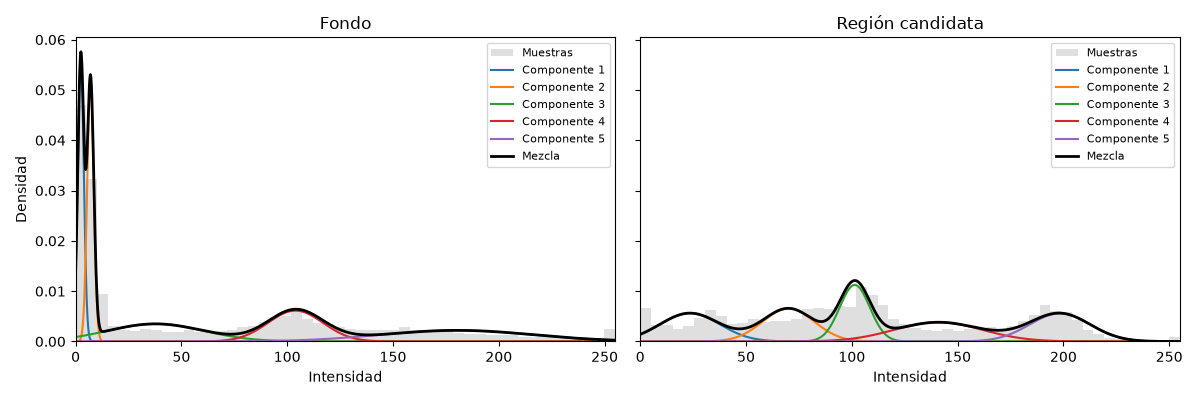

In [15]:
def gaussian_pdf(x, mean, variance):
    return np.exp(-0.5 * (x - mean) ** 2 / variance) / np.sqrt(2 * np.pi * variance)


intensity_axis = np.linspace(0, 255, 1024)
initial_models = [
    (background_pixels, bg_weights, bg_means, bg_variances, "Fondo"),
    (foreground_pixels, fg_weights, fg_means, fg_variances, "Región candidata"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (samples, weights, means, variances, title) in zip(axes, initial_models):
    ax.hist(samples, bins=50, density=True, alpha=0.25, color="gray", label="Muestras")
    mixture = np.zeros_like(intensity_axis)
    for k, (weight, mean, variance) in enumerate(zip(weights, means, variances)):
        component = weight * gaussian_pdf(intensity_axis, mean, variance)
        mixture += component
        ax.plot(intensity_axis, component, label=f"Componente {k + 1}")
    ax.plot(intensity_axis, mixture, color="black", linewidth=2, label="Mezcla")
    ax.set(title=title, xlabel="Intensidad", xlim=(0, 255))
    ax.legend(fontsize=8)
axes[0].set_ylabel("Densidad")
plt.tight_layout()
plt.show()

### 5.4. Asignación de componentes

Con la clase $a$ fija, asignamos cada intensidad al componente de mayor contribución ponderada:

$$k_i=\arg\max_k w_{ak}\mathcal N(x_i;\mu_{ak},\sigma_{ak}^2)
=\arg\min_k d_{ak}(x_i),$$

$$d_{ak}(x)=-\log w_{ak}+\frac12\log(2\pi\sigma_{ak}^2)
+\frac{(x-\mu_{ak})^2}{2\sigma_{ak}^2}.$$

Trabajar en logaritmos evita que una exponencial muy pequeña se redondee a cero. Un componente con peso cero recibe costo $+\infty$ y queda inactivo. La asignación es **dura**: cada píxel elige un componente, sin responsabilidades fraccionarias de EM.

Esta operación cambia $k_i$, **no** la etiqueta $\alpha_i$. El mapa muestra índices locales a cada clase: el componente 1 del fondo no tiene por qué parecerse al componente 1 del primer plano.

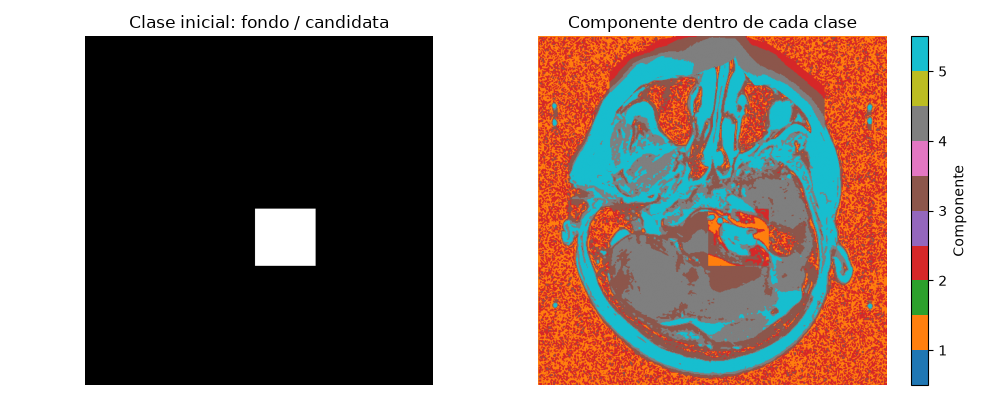

Píxeles por componente de fondo: [48693 58231 43785 52752 51207]
Píxeles por componente candidato: [1519 1483 1633 1214 1627]


In [17]:
def component_costs(samples, weights, means, variances):
    log_weights = np.full_like(weights, -np.inf)
    np.log(weights, out=log_weights, where=weights > 0)
    return (
        -log_weights
        + 0.5 * np.log(2 * np.pi * variances)
        + 0.5 * (samples[..., None] - means) ** 2 / variances
    )


bg_components = component_costs(
    background_pixels, bg_weights, bg_means, bg_variances
).argmin(axis=-1)
fg_components = component_costs(
    foreground_pixels, fg_weights, fg_means, fg_variances
).argmin(axis=-1)
component_map = np.zeros_like(labels)
component_map[labels == 0] = bg_components
component_map[labels == 1] = fg_components

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(labels, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Clase inicial: fondo / candidata")
plot = axes[1].imshow(component_map + 1, cmap="tab10", vmin=0.5, vmax=5.5)
axes[1].set_title("Componente dentro de cada clase")
fig.colorbar(plot, ax=axes[1], ticks=range(1, K + 1), label="Componente")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
print("Píxeles por componente de fondo:", np.bincount(bg_components, minlength=K))
print("Píxeles por componente candidato:", np.bincount(fg_components, minlength=K))